## Imports and setup

In [114]:
import os
import json
import sys
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import medmnist
from medmnist import INFO

import importlib
import src.model3d as m3d

importlib.invalidate_caches()
importlib.reload(m3d)

Small3DCNN = m3d.Small3DCNN 

from src.train_utils import TrainConfig, set_seed, train_one_epoch, evaluate, save_json, save_checkpoint

# Resolve repo root:
# - If running inside notebooks/, go one level up
# - If already at repo root, keep it
try:
    NOTEBOOK_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    # In Jupyter, __file__ usually doesn't exist
    NOTEBOOK_DIR = os.getcwd()

# If this notebook lives in "notebooks/", repo root is its parent
if os.path.basename(NOTEBOOK_DIR) == "notebooks":
    REPO_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, ".."))
else:
    # Fall back to "one level up" behavior
    REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Add repo root so `from src...` imports work
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

# Run-specific results directory
RESULTS_ROOT = os.path.join(REPO_ROOT, "results")
RUN_ID = datetime.now().strftime("%Y-%m-%d_%H.%M.%S")
RUN_DIR = os.path.join(RESULTS_ROOT, "runs", RUN_ID)
FIG_DIR = os.path.join(RUN_DIR, "figures")

os.makedirs(FIG_DIR, exist_ok=True)
print("Saving this run to:", RUN_DIR)


# ----------- Saving locations -----------

# Saving location for metrics 
metrics_path = os.path.join(RUN_DIR, "metrics.json")

# Saving location for plots 
train_loss_path = os.path.join(FIG_DIR, f"train_loss_{RUN_ID}.png")
confuson_matrix_path = os.path.join(FIG_DIR, f"confusion_matrix_{RUN_ID}.png")
table_path = os.path.join(FIG_DIR, f"results_table_{RUN_ID}.png")


Saving this run to: /Users/erem/Desktop/Desktop Folder/UBC/Fifth Year/Term 2/Cmpe 401/lung-nodule-3d/results/runs/2026-03-04_18.51.01


## Config and device

In [115]:
cfg = TrainConfig(
    epochs=50,
    lr=3e-4,
    weight_decay=1e-4,
    batch_size=128,

    # In macOS notebooks, multiprocessing can break with custom collate_fn
    # Keeping num_workers=0 avoids worker spawn/pickling issues
    num_workers=0,

    # Seed is set for more repeatable runs
    seed=42,

    # Default decision threshold for converting probability -> class label
    threshold=0.5
)

# Use GPU if available, otherwise CPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# Set random seeds across libraries to reduce run-to-run variation
set_seed(cfg.seed)

# Save plots and figures into this folder
os.makedirs("results/figures", exist_ok=True)

device: cpu


## Load NoduleMNIST3D

In [116]:
data_flag = "nodulemnist3d"
info = INFO[data_flag]

# Dataset class name is stored as a string in INFO; fetch the class object
DataClass = getattr(medmnist, info["python_class"])

print("Task:", info["task"])
print("Labels:", info["label"])
print("Channels:", info["n_channels"])

# Some MedMNIST versions omit n_classes; fallback to the number of labels
n_classes = info.get("n_classes", len(info["label"]))
print("Num classes:", n_classes)

Task: binary-class
Labels: {'0': 'benign', '1': 'malignant'}
Channels: 1
Num classes: 2


## Dataset Splitting

In [117]:
# MedMNIST downloads automatically to its cache location when download=True
train_ds = DataClass(split="train", download=True)
val_ds   = DataClass(split="val", download=True)
test_ds  = DataClass(split="test", download=True)

# Quick check - dataset sizes should match expected counts
print("sizes:", len(train_ds), len(val_ds), len(test_ds))

sizes: 1158 165 310


Important note: MedMNIST labels are typically shaped (N, 1). We’ll flatten later.

## Handle class imbalance helper
### Using `pos_weight`

In [118]:
def get_label_array(ds):
    # ds[i] -> (x, y) where y is shape (1,)
    y = [int(np.array(ds[i][1]).reshape(-1)[0]) for i in range(len(ds))]
    return np.array(y, dtype=int)

y_train = get_label_array(train_ds)
n_pos = int((y_train == 1).sum())
n_neg = int((y_train == 0).sum())

print("train positives:", n_pos, "train negatives:", n_neg)

# pos_weight = neg/pos is the standard weighting for BCEWithLogitsLoss
pos_weight_value = (n_neg / max(n_pos, 1))
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32, device=device)

print("pos_weight:", pos_weight_value)

train positives: 295 train negatives: 863
pos_weight: 2.925423728813559


## DataLoader

In [119]:
# collate_fn controls how a list of dataset samples becomes a batch
def collate_fn(batch, train=False):
    xs, ys = zip(*batch)

    x = torch.tensor(np.stack(xs)).float()
    y = torch.tensor(np.stack(ys)).long()

    # Ensure x is (B, 1, D, H, W)
    if x.ndim == 4:
        x = x.unsqueeze(1)

    # ---- Normalization (per-volume standardization) ----
    # Standardize each sample independently: (x - mean) / std
    # This stabilizes training when intensity scales vary.
    eps = 1e-6
    mean = x.mean(dim=(2, 3, 4), keepdim=True)
    std = x.std(dim=(2, 3, 4), keepdim=True)
    x = (x - mean) / (std + eps)

    # ---- Lightweight 3D augmentation (train only) ----
    if train:
        # Random flips along each axis (depth/height/width)
        if torch.rand(1).item() < 0.5:
            x = torch.flip(x, dims=[2])  # flip depth
        if torch.rand(1).item() < 0.5:
            x = torch.flip(x, dims=[3])  # flip height
        if torch.rand(1).item() < 0.5:
            x = torch.flip(x, dims=[4])  # flip width

        # Small gaussian noise
        if torch.rand(1).item() < 0.3:
            x = x + 0.05 * torch.randn_like(x)

    return x, y

# pin_memory only helps when using CUDA; on CPU it can be left False
train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=False,
    collate_fn=lambda b: collate_fn(b, train=True)
)

val_loader = DataLoader(
    val_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=False,
    collate_fn=lambda b: collate_fn(b, train=False)
)

test_loader = DataLoader(
    test_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=False,
    collate_fn=lambda b: collate_fn(b, train=False)
)

## Data Visualization

x0 shape: (1, 28, 28, 28) y0: [0]


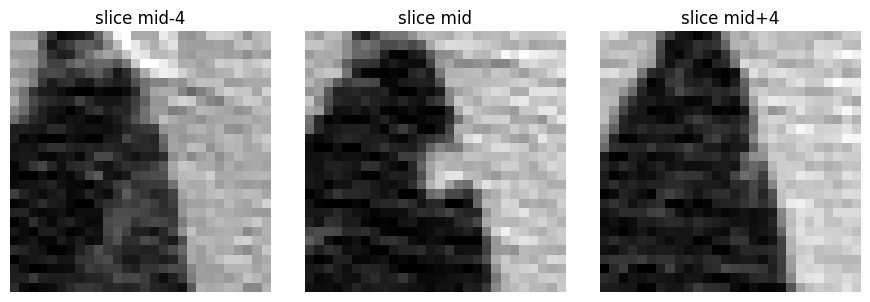

batch shapes: torch.Size([128, 1, 28, 28, 28]) torch.Size([128, 1])


In [120]:
# Inspect a single sample to confirm shapes and label format
x0, y0 = train_ds[0]
x0 = np.array(x0)
print("x0 shape:", x0.shape, "y0:", y0)

# For plotting, drop the channel dimension if present: (1, D, H, W) -> (D, H, W)
vol = x0[0] if x0.ndim == 4 else x0
mid = vol.shape[0] // 2

# Plot a few slices around the center depth
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(vol[mid-4], cmap="gray"); axes[0].set_title("slice mid-4"); axes[0].axis("off")
axes[1].imshow(vol[mid],   cmap="gray"); axes[1].set_title("slice mid");   axes[1].axis("off")
axes[2].imshow(vol[mid+4], cmap="gray"); axes[2].set_title("slice mid+4"); axes[2].axis("off")
plt.tight_layout()
plt.show()

# Confirm the DataLoader batch matches the 3D CNN expectation
xb, yb = next(iter(train_loader))
print("batch shapes:", xb.shape, yb.shape)

## Model, Loss, and Optimizer

In [121]:
# Model outputs a single logit for binary classification
model = Small3DCNN(dropout_p=0.3).to(device)

# BCEWithLogitsLoss expects raw logits
# Accounting for class imbalance to improve sensitivity score
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# AdamW is a stable default for this small CNN baseline
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

# Optimizer Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",       # want to maximize AUROC
    factor=0.5,       # reduce LR by half
    patience=3,       # wait 3 epochs without improvement
    min_lr=1e-6
)

print("num params:", sum(p.numel() for p in model.parameters()))

num params: 291585


## Training loop with metrics logging

In [122]:
# Store training loss and validation metrics per epoch
history = {"train_loss": [], "val": []}
best_score = -1.0
best_epoch = -1

for epoch in range(1, cfg.epochs + 1):
    # One full pass over the training set
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)

    # Evaluate on validation set at the current threshold
    val_metrics = evaluate(model, val_loader, device, threshold=cfg.threshold)

    # Step the scheduler using validation AUROC
    score_for_sched = val_metrics["auroc"] if val_metrics["auroc"] is not None else val_metrics["f1"]
    scheduler.step(score_for_sched)
    
    print("lr:", optimizer.param_groups[0]["lr"])

    # Print LR each epoch
    history["train_loss"].append(train_loss)
    history["val"].append(val_metrics)

    print(
        f"epoch {epoch:02d} | loss {train_loss:.4f} | "
        f"val auroc {val_metrics['auroc']} | val f1 {val_metrics['f1']:.4f}"
    )

    # Saving location for results 
    best_ckpt_path = os.path.join(RUN_DIR, "best.pt")
    
    # Checkpoint selection: prefer AUROC when available; fallback to F1
    score = val_metrics["auroc"] if val_metrics["auroc"] is not None else val_metrics["f1"]
    if score > best_score:
        best_score = score
        best_epoch = epoch
        save_checkpoint(
            best_ckpt_path,
            model,
            optimizer,
            epoch,
            {"val_metrics": val_metrics, "config": cfg.__dict__}
        )

# Save training history and the best epoch so results are reproducible
save_json(metrics_path, {"history": history, "best_epoch": best_epoch})
print("best_epoch:", best_epoch, "best_score:", best_score)

lr: 0.0003
epoch 01 | loss 0.9880 | val auroc 0.6680216802168022 | val f1 0.4124


lr: 0.0003
epoch 02 | loss 0.8469 | val auroc 0.7435152922957801 | val f1 0.4286


lr: 0.0003
epoch 03 | loss 0.8210 | val auroc 0.8083623693379791 | val f1 0.0465


lr: 0.0003
epoch 04 | loss 0.8732 | val auroc 0.7928765001935735 | val f1 0.4818


lr: 0.0003
epoch 05 | loss 0.8044 | val auroc 0.781262098335269 | val f1 0.6098


...

lr: 1e-06
epoch 46 | loss 0.6633 | val auroc 0.818621757646148 | val f1 0.6292


lr: 1e-06
epoch 47 | loss 0.6519 | val auroc 0.819008904374758 | val f1 0.6022


lr: 1e-06
epoch 48 | loss 0.7607 | val auroc 0.8164924506387921 | val f1 0.6154


lr: 1e-06
epoch 49 | loss 0.6233 | val auroc 0.8176538908246226 | val f1 0.6154


lr: 1e-06
epoch 50 | loss 0.6501 | val auroc 0.8178474641889276 | val f1 0.6154
best_epoch: 8 best_score: 0.8224932249322493


## Tuning Decision Threshold

In [123]:
# Collect logits and labels from a loader (used for threshold tuning)
@torch.no_grad()
def get_logits_and_labels(model, loader, device):
    model.eval()
    all_logits, all_y = [], []
    for x, y in loader:
        x = x.to(device)
        logits = model(x).cpu().numpy()
        all_logits.append(logits)

        # Labels arrive as shape (B, 1); flatten to (B,)
        all_y.append(y.numpy().reshape(-1))
    return np.concatenate(all_y).astype(int), np.concatenate(all_logits)

# Use validation set to choose a threshold (instead of guessing 0.5)
y_val, logits_val = get_logits_and_labels(model, val_loader, device)

from src.metrics import compute_binary_metrics

# Sweep thresholds and select the one that maximizes F1 on validation
thresholds = np.linspace(0.05, 0.95, 19)
rows = []
best = None

for t in thresholds:
    m = compute_binary_metrics(y_val, logits_val, threshold=float(t))
    row = (t, m["f1"], m["sensitivity"], m["specificity"], m["accuracy"], m["auroc"])
    rows.append(row)

    # Track best threshold by F1 score
    if best is None or m["f1"] > best[1]:
        best = row

print("best by F1:", best)

best by F1: (np.float64(0.65), 0.704225352112676, 0.5952380952380952, 0.967479674796748, 0.8727272727272727, 0.8178474641889276)


## Plot training curve

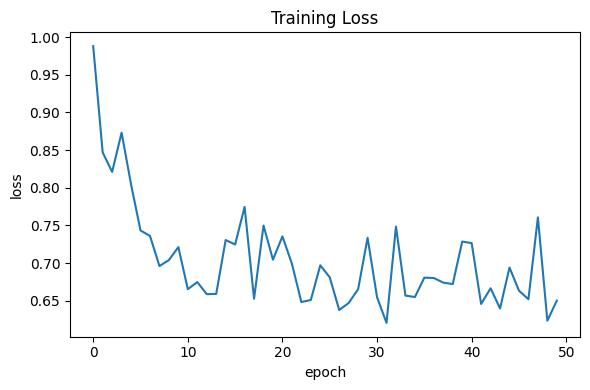

In [124]:
plt.figure(figsize=(6,4))
plt.plot(history["train_loss"])
plt.title("Training Loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.tight_layout()
plt.savefig(train_loss_path, dpi=200)
plt.show()

## Test evaluation 
### With default threshold and write into metrics.json

In [125]:
# Evaluate test set using the default threshold (0.5 unless changed)
test_metrics = evaluate(model, test_loader, device, threshold=cfg.threshold)
print(test_metrics)

# Store metrics in the same JSON file as training history
with open(metrics_path, "r") as f:
    m = json.load(f)
m["test_default_threshold"] = test_metrics
with open(metrics_path, "w") as f:
    json.dump(m, f, indent=2)

{'auroc': 0.8711255081300813, 'f1': 0.5987261146496815, 'accuracy': 0.7967741935483871, 'sensitivity': 0.734375, 'specificity': 0.8130081300813008, 'confusion_matrix': [[200, 46], [17, 47]]}


## Confusion matrix figure

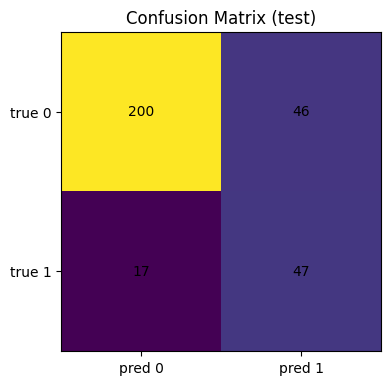

In [ ]:
cm = np.array(test_metrics["confusion_matrix"])
plt.figure(figsize=(4,4))
plt.imshow(cm)
plt.title("Confusion Matrix (test)")

# Label mapping for this dataset:
#   0 -> benign  (negative class)
#   1 -> malignant (positive class)

plt.xticks([0,1], ["pred 0", "pred 1"])
plt.yticks([0,1], ["true 0", "true 1"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i,j]), ha="center", va="center")
plt.tight_layout()
plt.savefig(confuson_matrix_path, dpi=200)
plt.show()

## Threshold tuning on validation set

In [127]:
# Recompute best threshold in a structured dict format for saving
@torch.no_grad()
def get_logits_and_labels(model, loader, device):
    model.eval()  # eval mode for consistent inference (no dropout, BN uses running stats)

    all_logits, all_y = [], []
    for x, y in loader:
        x = x.to(device)                     # move batch to CPU/GPU
        logits = model(x).cpu().numpy()       # forward pass -> raw logits (B,)
        all_logits.append(logits)

        all_y.append(y.numpy().reshape(-1))   # labels often come as (B,1); flatten to (B,)

    # combine batches into full arrays for the whole split
    return np.concatenate(all_y).astype(int), np.concatenate(all_logits)

# get validation labels + logits once, then sweep thresholds cheaply
y_val, logits_val = get_logits_and_labels(model, val_loader, device)

# try a range of thresholds; pick the one that maximizes F1 on validation
thresholds = np.linspace(0.05, 0.95, 19)
rows = []
best = None

for t in thresholds:
    met = compute_binary_metrics(y_val, logits_val, threshold=float(t))  # metrics at this threshold
    row = {
        "threshold": float(t),
        "f1": met["f1"],
        "sensitivity": met["sensitivity"],
        "specificity": met["specificity"],
        "accuracy": met["accuracy"],
        "auroc": met["auroc"],
    }
    rows.append(row)

    if best is None or row["f1"] > best["f1"]:
        best = row

print("best threshold by F1:", best)


best threshold by F1: {'threshold': 0.65, 'f1': 0.704225352112676, 'sensitivity': 0.5952380952380952, 'specificity': 0.967479674796748, 'accuracy': 0.8727272727272727, 'auroc': 0.8178474641889276}


## Test evaluation with tuned threshold

In [128]:
# evaluate test set once using the chosen threshold
best_threshold = best["threshold"]
test_metrics_tuned = evaluate(model, test_loader, device, threshold=best_threshold)
print("threshold:", best_threshold)
print(test_metrics_tuned)

# write tuned-threshold results into the metrics.json file
with open(metrics_path, "r") as f:
    m = json.load(f)
m["best_threshold_val_f1"] = best
m["test_tuned_threshold"] = test_metrics_tuned
with open(metrics_path, "w") as f:
    json.dump(m, f, indent=2)

threshold: 0.65
{'auroc': 0.8711255081300813, 'f1': 0.5984251968503937, 'accuracy': 0.8354838709677419, 'sensitivity': 0.59375, 'specificity': 0.8983739837398373, 'confusion_matrix': [[221, 25], [26, 38]]}


## Logistic regression baseline 
### With flattened voxels

In [129]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

def flatten_dataset(ds):
    X, y = [], []
    for i in range(len(ds)):
        x_i, y_i = ds[i]
        x_i = np.array(x_i).astype(np.float32)  # expected (1, 28, 28, 28)
        X.append(x_i.reshape(-1))               # flatten -> (28*28*28,)

        y.append(int(np.array(y_i).reshape(-1)[0]))  # label stored as (1,); convert to int

    return np.stack(X), np.array(y)

# build feature matrices for each split
X_train, y_train = flatten_dataset(train_ds)
X_val_lr, y_val_lr = flatten_dataset(val_ds)
X_test, y_test = flatten_dataset(test_ds)

# standardize features + train class-weighted logistic regression
clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, class_weight="balanced")
)
clf.fit(X_train, y_train)

# decision_function gives raw scores (logit-like) suitable for AUROC + thresholding
logits_test_lr = clf.decision_function(X_test)
lr_metrics = compute_binary_metrics(y_test, logits_test_lr, threshold=0.5)
print(lr_metrics)

# save baseline results into metrics.json
with open(metrics_path, "r") as f:
    m = json.load(f)
m["logreg_baseline_test"] = lr_metrics
with open(metrics_path, "w") as f:
    json.dump(m, f, indent=2)

{'auroc': 0.8226626016260161, 'f1': 0.5538461538461539, 'accuracy': 0.8129032258064516, 'sensitivity': 0.5625, 'specificity': 0.8780487804878049, 'confusion_matrix': [[216, 30], [28, 36]]}


## Results summary table

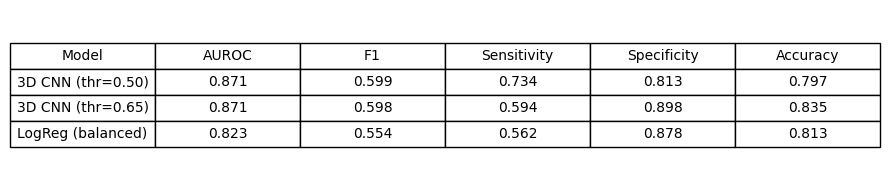

In [130]:
# Helper to pull consistent metrics into a row
def row_from_metrics(name, met):
    return [
        name,
        met.get("auroc", None),
        met.get("f1", None),
        met.get("sensitivity", None),
        met.get("specificity", None),
        met.get("accuracy", None),
    ]

rows_table = []
rows_table.append(row_from_metrics("3D CNN (thr=0.50)", test_metrics))
rows_table.append(row_from_metrics(f"3D CNN (thr={best_threshold:.2f})", test_metrics_tuned))
rows_table.append(row_from_metrics("LogReg (balanced)", lr_metrics))

col_labels = ["Model", "AUROC", "F1", "Sensitivity", "Specificity", "Accuracy"]

fig, ax = plt.subplots(figsize=(9, 2))
ax.axis("off")

# Format numbers for display
def fmt(x):
    if x is None:
        return "-"
    return f"{x:.3f}"

cell_text = []
for r in rows_table:
    cell_text.append([r[0]] + [fmt(v) for v in r[1:]])

table = ax.table(
    cellText=cell_text,
    colLabels=col_labels,
    loc="center",
    cellLoc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.4)

plt.tight_layout()
plt.savefig(table_path, dpi=250)
plt.show()